<a href="https://colab.research.google.com/github/Mateutm/TFG-Sintetic_Image_Classification/blob/main/TFG.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

###Instalación de paquetes


In [ ]:
!pip install tensorboardX
!pip install dataset
!pip install templates

###Imports


In [ ]:
from imageio.v2 import imread
import os
import random
import torch
from torch.utils.data import DataLoader
from torchvision import transforms
import numpy as np
from tensorboardX import SummaryWriter
from tensorboard import program
import torch
import torch.optim as optim
import torch.nn as nn
from scipy.io import savemat
import shutil
from google.colab import drive
import torch.nn.functional as F
import sys
from tqdm.auto import tqdm
import matplotlib.pyplot as plt

Montar el drive para los datos

In [ ]:
drive.mount('/content/drive')
PATH = '/content/drive/MyDrive/TFG/'

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


### Analisi de los datos

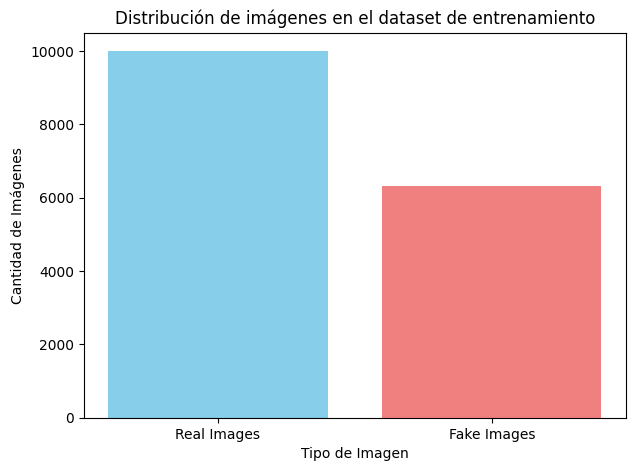

In [ ]:
real_count = len(os.listdir(PATH + 'DATASET/train/Real'))
fake_count = len(os.listdir(PATH + 'DATASET/train/Fake'))

labels = ['Real Images', 'Fake Images']
counts = [real_count, fake_count]


plt.figure(figsize=(7, 5))
plt.bar(labels, counts, color=['skyblue', 'lightcoral'])

plt.title("Distribución de imágenes en el dataset de entrenamiento")
plt.xlabel("Tipo de Imagen")
plt.ylabel("Cantidad de Imágenes")
plt.show()

###dataset.py

In [ ]:

DATABASE = PATH + 'DATASET/'

DATASETS = {
    'Real': 0,
    'Fake': 1
}


class DatasetInstance:
    def __init__(self, label_name, label, datatype, img_size, map_size, norm, seed, bs, drop_last):
        self.img_size = img_size
        self.map_size = map_size

        self.transform = transforms.Compose([
            transforms.ToPILImage(),
            transforms.Resize(img_size),
            transforms.ToTensor(),
            transforms.Normalize(*norm)
        ])

        self.transform_mask = transforms.Compose([
            transforms.ToPILImage(),
            transforms.Resize(map_size),
            transforms.Grayscale(num_output_channels=1),
            transforms.ToTensor()
        ])

        self.label_name = label_name
        self.label = label
        self.datatype = datatype
        self.data_dir = '{0}{1}/{2}/'.format(DATABASE, self.datatype, self.label_name)
        files = os.listdir(self.data_dir)
        if self.datatype != 'test':
            random.Random(seed).shuffle(files)
        self.images = ['{0}/{1}'.format(self.data_dir, _) for _ in files]
        self.loader = DataLoader(self, num_workers=0, batch_size=bs, shuffle=(self.datatype != 'test'),
                                 drop_last=drop_last, pin_memory=True)
        self.generator = self.get_batch()

        print('Constructed Dataset `{0}` of size `{1}`'.format(self.data_dir, self.__len__()))

    def load_image(self, path):
        return self.transform(imread(path))

    def load_mask(self, path):
        return self.transform_mask(imread(path))

    def __getitem__(self, index):
        im_name = self.images[index]
        img = self.load_image(im_name)
        if self.label_name == 'Real':
            msk = torch.zeros(1, 19, 19)
        else:
            msk = self.load_mask(im_name.replace('Fake/', 'Mask/'))
        return {'img': img, 'msk': msk, 'lab': self.label, 'im_name': im_name}

    def __len__(self):
        return len(self.images)

    def get_batch(self):
        if self.datatype == 'test':
            for batch in self.loader:
                yield batch
        else:
            while True:
                for batch in self.loader:
                    yield batch


class Dataset:
    def __init__(self, datatype, bs, img_size, map_size, norm, seed):
        drop_last = datatype == 'train'
        datasets = [DatasetInstance(_, DATASETS[_], datatype, img_size, map_size, norm, seed, bs, drop_last) for _ in
                    DATASETS]
        drop_last = datatype == 'train' or datatype == 'eval'
        self.datasets = datasets

    def get_batch(self, index=-1):
        batch = None
        device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
        if index == -1:
            batch = [next(_.generator, None) for _ in self.datasets]
        else:
            batch = [next(self.datasets[index].generator, None)]
        if any([_ is None for _ in batch]):
            return None
        img = torch.cat([_['img'] for _ in batch], dim=0).to(device)#.cuda()
        msk = torch.cat([_['msk'] for _ in batch], dim=0).to(device)#.cuda()
        lab = torch.cat([_['lab'] for _ in batch], dim=0).to(device)#.cuda()
        #im_name = torch.cat([_['im_name'] for _ in batch], dim=0)
        return {'img': img, 'msk': msk, 'lab': lab}


###Templates.py


In [ ]:
def get_templates():
  templates_list = []
  device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
  for i in range(10):
    img = imread(PATH + 'FFD_CVPR2020/MCT/template{:d}.png'.format(i))
    templates_list.append(transforms.functional.to_tensor(img)[0:1,0:19,0:19])
  templates = torch.stack(templates_list).to(device)#.cuda()
  templates = templates.squeeze(1)
  return templates



###Xception.py

In [ ]:


class SeparableConv2d(nn.Module):
  def __init__(self, c_in, c_out, ks, stride=1, padding=0, dilation=1, bias=False):
    super(SeparableConv2d, self).__init__()
    self.c = nn.Conv2d(c_in, c_in, ks, stride, padding, dilation, groups=c_in, bias=bias)
    self.pointwise = nn.Conv2d(c_in, c_out, 1, 1, 0, 1, 1, bias=bias)

  def forward(self, x):
    x = self.c(x)
    x = self.pointwise(x)
    return x

class Block(nn.Module):
  def __init__(self, c_in, c_out, reps, stride=1, start_with_relu=True, grow_first=True):
    super(Block, self).__init__()

    self.skip = None
    self.skip_bn = None
    if c_out != c_in or stride!= 1:
      self.skip = nn.Conv2d(c_in, c_out, 1, stride=stride, bias=False)
      self.skip_bn = nn.BatchNorm2d(c_out)

    self.relu = nn.ReLU(inplace=True)

    rep = []
    c = c_in
    if grow_first:
      rep.append(self.relu)
      rep.append(SeparableConv2d(c_in, c_out, 3, stride=1, padding=1, bias=False))
      rep.append(nn.BatchNorm2d(c_out))
      c = c_out

    for i in range(reps - 1):
      rep.append(self.relu)
      rep.append(SeparableConv2d(c, c, 3, stride=1, padding=1, bias=False))
      rep.append(nn.BatchNorm2d(c))

    if not grow_first:
      rep.append(self.relu)
      rep.append(SeparableConv2d(c_in, c_out, 3, stride=1, padding=1, bias=False))
      rep.append(nn.BatchNorm2d(c_out))

    if not start_with_relu:
      rep = rep[1:]
    else:
      rep[0] = nn.ReLU(inplace=False)

    if stride != 1:
      rep.append(nn.MaxPool2d(3, stride, 1))
    self.rep = nn.Sequential(*rep)

  def forward(self, inp):
    x = self.rep(inp)

    if self.skip is not None:
      y = self.skip(inp)
      y = self.skip_bn(y)
    else:
      y = inp

    x += y
    return x

class RegressionMap(nn.Module):
  def __init__(self, c_in):
    super(RegressionMap, self).__init__()
    self.c = SeparableConv2d(c_in, 1, 3, stride=1, padding=1, bias=False)
    self.s = nn.Sigmoid()

  def forward(self, x):
    mask = self.c(x)
    mask = self.s(mask)
    return mask, None

class TemplateMap(nn.Module):
  def __init__(self, c_in, templates):
    super(TemplateMap, self).__init__()
    self.c = Block(c_in, 364, 2, 2, start_with_relu=True, grow_first=False)
    self.l = nn.Linear(364, 10)
    self.relu = nn.ReLU(inplace=True)

    self.templates = templates

  def forward(self, x):
    v = self.c(x)
    v = self.relu(v)
    v = F.adaptive_avg_pool2d(v, (1,1))
    v = v.view(v.size(0), -1)
    v = self.l(v)
    mask = torch.mm(v, self.templates.reshape(10,361))
    mask = mask.reshape(x.shape[0], 1, 19, 19)

    return mask, v

class PCATemplateMap(nn.Module):
  def __init__(self, templates):
    super(PCATemplateMap, self).__init__()
    self.templates = templates

  def forward(self, x):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    fe = x.view(x.shape[0], x.shape[1], x.shape[2]*x.shape[3])
    fe = torch.transpose(fe, 1, 2)
    mu = torch.mean(fe, 2, keepdim=True)
    fea_diff = fe - mu

    cov_fea = torch.bmm(fea_diff, torch.transpose(fea_diff, 1, 2))
    B = self.templates.reshape(1, 10, 361).repeat(x.shape[0], 1, 1)
    D = torch.bmm(torch.bmm(B, cov_fea), torch.transpose(B, 1, 2))
    eigen_value, eigen_vector = D.symeig(eigenvectors=True)
    index = torch.tensor([9]).to(device)#.cuda()
    eigen = torch.index_select(eigen_vector, 2, index)

    v = eigen.squeeze(-1)
    mask = torch.mm(v, self.templates.reshape(10, 361))
    mask = mask.reshape(x.shape[0], 1, 19, 19)
    return mask, v

class Xception(nn.Module):
  """
  Xception optimized for the ImageNet dataset, as specified in
  https://arxiv.org/pdf/1610.02357.pdf
  """
  def __init__(self, maptype, templates, num_classes=1000):
    super(Xception, self).__init__()
    self.num_classes = num_classes

    self.conv1 = nn.Conv2d(3, 32, 3,2, 0, bias=False)
    self.bn1 = nn.BatchNorm2d(32)
    self.relu = nn.ReLU(inplace=True)

    self.conv2 = nn.Conv2d(32,64,3,bias=False)
    self.bn2 = nn.BatchNorm2d(64)

    self.block1=Block(64,128,2,2,start_with_relu=False,grow_first=True)
    self.block2=Block(128,256,2,2,start_with_relu=True,grow_first=True)
    self.block3=Block(256,728,2,2,start_with_relu=True,grow_first=True)
    self.block4=Block(728,728,3,1,start_with_relu=True,grow_first=True)
    self.block5=Block(728,728,3,1,start_with_relu=True,grow_first=True)
    self.block6=Block(728,728,3,1,start_with_relu=True,grow_first=True)
    self.block7=Block(728,728,3,1,start_with_relu=True,grow_first=True)
    self.block8=Block(728,728,3,1,start_with_relu=True,grow_first=True)
    self.block9=Block(728,728,3,1,start_with_relu=True,grow_first=True)
    self.block10=Block(728,728,3,1,start_with_relu=True,grow_first=True)
    self.block11=Block(728,728,3,1,start_with_relu=True,grow_first=True)
    self.block12=Block(728,1024,2,2,start_with_relu=True,grow_first=False)

    self.conv3 = SeparableConv2d(1024,1536,3,1,1)
    self.bn3 = nn.BatchNorm2d(1536)

    self.conv4 = SeparableConv2d(1536,2048,3,1,1)
    self.bn4 = nn.BatchNorm2d(2048)

    self.last_linear = nn.Linear(2048, num_classes)

    if maptype == 'none':
      self.map = [1, None]
    elif maptype == 'reg':
      self.map = RegressionMap(728)
    elif maptype == 'tmp':
      self.map = TemplateMap(728, templates)
    elif maptype == 'pca_tmp':
      self.map = PCATemplateMap(728)
    else:
      print('Unknown map type: `{0}`'.format(maptype))
      sys.exit()

  def features(self, input):
    x = self.conv1(input)
    x = self.bn1(x)
    x = self.relu(x)

    x = self.conv2(x)
    x = self.bn2(x)
    x = self.relu(x)

    x = self.block1(x)
    x = self.block2(x)
    x = self.block3(x)
    x = self.block4(x)
    x = self.block5(x)
    x = self.block6(x)
    x = self.block7(x)
    mask, vec = self.map(x)
    x = x * mask
    x = self.block8(x)
    x = self.block9(x)
    x = self.block10(x)
    x = self.block11(x)
    x = self.block12(x)
    x = self.conv3(x)
    x = self.bn3(x)
    x = self.relu(x)

    x = self.conv4(x)
    x = self.bn4(x)
    return x, mask, vec

  def logits(self, features):
    x = self.relu(features)
    x = F.adaptive_avg_pool2d(x, (1, 1))
    x = x.view(x.size(0), -1)
    x = self.last_linear(x)
    return x

  def forward(self, input):
    x, mask, vec = self.features(input)
    x = self.logits(x)
    return x, mask, vec

def init_weights(m):
  classname = m.__class__.__name__
  if classname.find('SeparableConv2d') != -1:
    m.c.weight.data.normal_(0.0, 0.01)
    if m.c.bias is not None:
      m.c.bias.data.fill_(0)
    m.pointwise.weight.data.normal_(0.0, 0.01)
    if m.pointwise.bias is not None:
      m.pointwise.bias.data.fill_(0)
  elif classname.find('Conv') != -1 or classname.find('Linear') != -1:
    m.weight.data.normal_(0.0, 0.01)
    if m.bias is not None:
      m.bias.data.fill_(0)
  elif classname.find('BatchNorm') != -1:
    m.weight.data.normal_(1.0, 0.01)
    m.bias.data.fill_(0)
  elif classname.find('LSTM') != -1:
    for i in m._parameters:
      if i.__class__.__name__.find('weight') != -1:
        i.data.normal_(0.0, 0.01)
      elif i.__class__.__name__.find('bias') != -1:
        i.bias.data.fill_(0)

class Model:
  def __init__(self, maptype='None', templates=None, num_classes=2, load_pretrain=True):
    model = Xception(maptype, templates, num_classes=num_classes)
    if load_pretrain:
      state_dict = torch.load('./xception-b5690688.pth')
      for name, weights in state_dict:
        if 'pointwise' in name:
          state_dict[name] = weights.unsqueeze(-1).unsqueeze(-1)
      del state_dict['fc.weight']
      del state_dict['fc.bias']
      model.load_state_dict(state_dict, False)
    else:
      model.apply(init_weights)
    self.model = model

  def save(self, epoch, optim, model_dir):
    state = {'net': self.model.state_dict(), 'optim': optim.state_dict()}
    torch.save(state, '{0}/{1:06d}.tar'.format(model_dir, epoch))
    print('Saved model `{0}`'.format(epoch))

  def load(self, epoch, model_dir):
    filename = '{0}{1:06d}.tar'.format(model_dir, epoch)
    print('Loading model from {0}'.format(filename))
    if os.path.exists(filename):
      state = torch.load(filename)
      self.model.load_state_dict(state['net'])
    else:
      print('Failed to load model from {0}'.format(filename))



###train.py

####Hiperparámteros

In [ ]:
MODEL_DIR = './models/'
BACKBONE = 'xcp'
MAPTYPE = 'tmp'
BATCH_SIZE = 15
MAX_EPOCHS = 5
STEPS_PER_EPOCH = 50
LEARNING_RATE = 0.001
WEIGHT_DECAY = 0.01
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

CONFIGS = {
  'xcp': {
          'img_size': (299, 299),
          'map_size': (19, 19),
          'norms': [[0.5] * 3, [0.5] * 3]
         },
  #'vgg': {
   #       'img_size': (299, 299),
  #        'map_size': (19, 19),
 #         'norms': [[0.485, 0.456, 0.406], [0.229, 0.224, 0.225]]
#         }
}

####Configuración de datasets

In [ ]:
CONFIG = CONFIGS[BACKBONE]

#if BACKBONE == 'xcp':
 # from xception import Model
#elif BACKBONE == 'vgg':
 # from vgg import Model

torch.backends.deterministic = True
SEED = 1
random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

DATA_TRAIN = Dataset('train', BATCH_SIZE, CONFIG['img_size'], CONFIG['map_size'], CONFIG['norms'], SEED)

DATA_EVAL = Dataset('eval', BATCH_SIZE, CONFIG['img_size'], CONFIG['map_size'], CONFIG['norms'], SEED)

Constructed Dataset `/content/drive/MyDrive/TFG/DATASET/train/Real/` of size `10000`
Constructed Dataset `/content/drive/MyDrive/TFG/DATASET/train/Fake/` of size `6309`
Constructed Dataset `/content/drive/MyDrive/TFG/DATASET/eval/Real/` of size `999`
Constructed Dataset `/content/drive/MyDrive/TFG/DATASET/eval/Fake/` of size `999`


####Definición del modelo

In [ ]:
TEMPLATES = None
if MAPTYPE in ['tmp', 'pca_tmp']:
  TEMPLATES = get_templates()

MODEL_NAME = '{0}_{1}'.format(BACKBONE, MAPTYPE)
MODEL_DIR = MODEL_DIR + MODEL_NAME + '/'

MODEL = Model(MAPTYPE, TEMPLATES, 2, False)

OPTIM = optim.Adam(MODEL.model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
MODEL.model.to(device)
LOSS_CSE = nn.CrossEntropyLoss().to(device)
LOSS_L1 = nn.L1Loss().to(device)
MAXPOOL = nn.MaxPool2d(19).to(device)

/tmp/ipykernel_12268/854757291.py:5: DeprecationWarning: Starting with ImageIO v3 the behavior of this function will switch to that of iio.v3.imread. To keep the current behavior (and make this warning disappear) use `import imageio.v2 as imageio` or call `imageio.v2.imread` directly.
  img = imread(PATH + 'FFD_CVPR2020/MCT/template{:d}.png'.format(i))


#### Entrenamiento

In [ ]:
losses_list = {
    'loss': [],
    'loss_l1': [],
    'loss_cse': [],
    'acc': []
}

def calculate_losses(batch):
  img = batch['img']
  msk = batch['msk']
  lab = batch['lab']
  x, mask, vec = MODEL.model(img)
  loss_l1 = LOSS_L1(mask, msk)
  loss_cse = LOSS_CSE(x, lab)
  loss = loss_l1 + loss_cse
  pred = torch.max(x, dim=1)[1]
  acc = (pred == lab).float().mean()

  losses_list['loss'].append(loss.item())
  losses_list['loss_l1'].append(loss_l1.item())
  losses_list['loss_cse'].append(loss_cse.item())
  losses_list['acc'].append(acc.item())

  return { 'loss': loss, 'loss_l1': loss_l1, 'loss_cse': loss_cse, 'acc': acc }

def process_batch(batch, mode):
  if mode == 'train':
    MODEL.model.train()
    current_batch_losses = calculate_losses(batch)
    OPTIM.zero_grad()
    current_batch_losses['loss'].backward()
    OPTIM.step()
  elif mode == 'eval':
    MODEL.model.eval()
    with torch.no_grad():
      current_batch_losses = calculate_losses(batch)
  return current_batch_losses

SUMMARY_WRITER = SummaryWriter(MODEL_DIR + 'logs/')
def write_tfboard(item, itr, name):
  SUMMARY_WRITER.add_scalar('{0}'.format(name), item, itr)

def run_step(e, s):
  current_losses_tensors = process_batch(DATA_TRAIN.get_batch(), 'train')
  return current_losses_tensors


def run_epoch(e):
  print('Epoch: {0}'.format(e))
  pbar = tqdm(range(STEPS_PER_EPOCH))

  for s in pbar:
      losses = run_step(e, s)
      pbar.set_description(f"Epoch {e}")
      pbar.set_postfix({k: f"{v.item():.3f}" for k, v in losses.items()})
  MODEL.save(e+1, OPTIM, MODEL_DIR)

LAST_EPOCH = 0
for e in range(LAST_EPOCH, MAX_EPOCHS):
  run_epoch(e)


Epoch: 0


  0%|          | 0/50 [00:00<?, ?it/s]

/tmp/ipykernel_12268/2776895582.py:43: DeprecationWarning: Starting with ImageIO v3 the behavior of this function will switch to that of iio.v3.imread. To keep the current behavior (and make this warning disappear) use `import imageio.v2 as imageio` or call `imageio.v2.imread` directly.
  return self.transform(imread(path))
/tmp/ipykernel_12268/2776895582.py:46: DeprecationWarning: Starting with ImageIO v3 the behavior of this function will switch to that of iio.v3.imread. To keep the current behavior (and make this warning disappear) use `import imageio.v2 as imageio` or call `imageio.v2.imread` directly.
  return self.transform_mask(imread(path))


Saved model `1`
Epoch: 1


  0%|          | 0/50 [00:00<?, ?it/s]

...

Saved model `3`
Epoch: 3


  0%|          | 0/50 [00:00<?, ?it/s]

Saved model `4`
Epoch: 4


  0%|          | 0/50 [00:00<?, ?it/s]

Saved model `5`


In [ ]:
import os
from tensorboard import

# Define el directorio de logs donde se encuentra el archivo de eventos
logdir = '/content/models/xcp_tmp/logs/'

# Asegúrate de que el directorio exista
if not os.path.exists(logdir):
    print(f"Error: El directorio de logs no se encuentra en {logdir}")
else:
    # Carga la extensión de TensorBoard en Colab
    %load_ext tensorboard
    # Inicia TensorBoard apuntando al directorio de logs
    %tensorboard --logdir {logdir}

SyntaxError: invalid syntax (3842124471.py, line 2)

###tets.py


#### Hiperparámetros

In [ ]:
MODEL_DIR = './models/'
BACKBONE = 'xcp'
MAPTYPE = 'tmp'
BATCH_SIZE = 200
MAX_EPOCHS = 15
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
CONFIGS = {
  'xcp': {
          'img_size': (299, 299),
          'map_size': (19, 19),
          'norms': [[0.5] * 3, [0.5] * 3]
         },
  'vgg': {
          'img_size': (299, 299),
          'map_size': (19, 19),
          'norms': [[0.485, 0.456, 0.406], [0.229, 0.224, 0.225]]
         }
}
CONFIG = CONFIGS[BACKBONE]

#### Inicilaización del modelo

In [ ]:
#if BACKBONE == 'xcp':
 # from xception import Model
#elif BACKBONE == 'vgg':
 # from vgg import Model

torch.backends.deterministic = True
SEED = 1
random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

def get_dataset():
  return Dataset('test', BATCH_SIZE, CONFIG['img_size'], CONFIG['map_size'], CONFIG['norms'], SEED)

DATA_TEST = None

TEMPLATES = None
if MAPTYPE in ['tmp', 'pca_tmp']:
  TEMPLATES = get_templates()

MODEL_NAME = '{0}_{1}'.format(BACKBONE, MAPTYPE)
MODEL_DIR = MODEL_DIR + MODEL_NAME + '/'

MODEL = Model(MAPTYPE, TEMPLATES, 2, False)

MODEL.model.to(device)#.cuda()
LOSS_CSE = nn.CrossEntropyLoss().to(device)#.cuda()
LOSS_L1 = nn.L1Loss().to(device)#.cuda()
MAXPOOL = nn.MaxPool2d(19).to(device)#.cuda()

#### Testing



In [ ]:
def calculate_losses(batch):
  img = batch['img']
  msk = batch['msk']
  lab = batch['lab']
  x, mask, vec = MODEL.model(img)
  loss_l1 = LOSS_L1(mask, msk)
  loss_cse = LOSS_CSE(x, lab)
  loss = loss_l1 + loss_cse
  pred = torch.max(x, dim=1)[1]
  acc = (pred == lab).float().mean()
  res = { 'lab': lab, 'msk': msk, 'score': x, 'pred': pred, 'mask': mask }
  results = {}
  for r in res:
    results[r] = res[r].squeeze().cpu().numpy()
  return { 'loss': loss, 'loss_l1': loss_l1, 'loss_cse': loss_cse, 'acc': acc }, results

def process_batch(batch, mode):
  MODEL.model.eval()
  with torch.no_grad():
    losses, results = calculate_losses(batch)
  return losses, results

def run_step(di, e, s, resultdir):
  batch = DATA_TEST.get_batch(di)
  if batch is None:
    return True
  losses, results = process_batch(batch, 'test')

  savemat('{0}{1}_{2}.mat'.format(resultdir, di, s), results)

  if s % 10 == 0:
    print('\r{0} - '.format(s) + ', '.join(['{0}: {1:.3f}'.format(_, losses[_].cpu().detach().numpy()) for _ in losses]), end='')
  return False

def run_epoch(di, e, resultdir):
  s = 0
  while True:
    s += 1
    is_done = run_step(di, e, s, resultdir)
    if is_done:
      break

LAST_EPOCH = 3
for e in range(LAST_EPOCH, MAX_EPOCHS, 1):
  resultdir = '{0}results/{1}/'.format(MODEL_DIR, e)
  if os.path.exists(resultdir):
    shutil.rmtree(resultdir)
  os.makedirs(resultdir, exist_ok=True)
  MODEL.load(e, MODEL_DIR)
  DATA_TEST = get_dataset()
  for di, d in enumerate(DATA_TEST.datasets):
    run_epoch(di, e, resultdir)
  print()

print('Testing complete')


Loading model from ./models/xcp_tmp/000003.tar
Constructed Dataset `/content/drive/MyDrive/TFG/DATASET/test/Real/` of size `9000`
Constructed Dataset `/content/drive/MyDrive/TFG/DATASET/test/Fake/` of size `4501`
20 - loss: 0.974, loss_l1: 0.366, loss_cse: 0.608, acc: 1.000
Loading model from ./models/xcp_tmp/000004.tar
Constructed Dataset `/content/drive/MyDrive/TFG/DATASET/test/Real/` of size `9000`
Constructed Dataset `/content/drive/MyDrive/TFG/DATASET/test/Fake/` of size `4501`
20 - loss: 32.809, loss_l1: 0.627, loss_cse: 32.182, acc: 0.340
Loading model from ./models/xcp_tmp/000005.tar
Constructed Dataset `/content/drive/MyDrive/TFG/DATASET/test/Real/` of size `9000`
Constructed Dataset `/content/drive/MyDrive/TFG/DATASET/test/Fake/` of size `4501`
20 - loss: 0.784, loss_l1: 0.045, loss_cse: 0.739, acc: 0.000
Loading model from ./models/xcp_tmp/000006.tar
Failed to load model from ./models/xcp_tmp/000006.tar
Constructed Dataset `/content/drive/MyDrive/TFG/DATASET/test/Real/` of s